In [1]:
import numpy as np
%matplotlib ipympl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
class ODE_solver:
    def __init__(self, box_limits, grid_shape):
        self.box_limits = np.array(box_limits) 
        self.grid_shape = grid_shape
        
        # discretize space
        self.x_grid = np.linspace(box_limits[0][0], box_limits[0][1], grid_shape[0])
        self.y_grid = np.linspace(box_limits[1][0], box_limits[1][1], grid_shape[1])
        self.z_grid = np.linspace(box_limits[2][0], box_limits[2][1], grid_shape[2])

    def get_velocity(self, pos, t):
        x, y, z = pos[0], pos[1], pos[2] # unpack position
        
        # define velocity field
        u = -y
        v =  x
        w =  0.5
        
        return np.array([u, v, w])

    def bounce(self, pos):
        for i in range(3):  
            min_pos, max_pos = self.box_limits[i]
            
            # if out of bounds
            if pos[i] > max_pos:
                pos[i] = max_pos - (pos[i] - max_pos) # mirror to other side

            elif pos[i] < min_pos:
                pos[i] = min_pos + (min_pos - pos[i])
                
        return pos

    def solve(self, initial_pos, t_start, t_end, dt): # using RK4
        time_steps = np.arange(t_start, t_end, dt)
        
        trajectory = [np.array(initial_pos)] # define trajectory list to store positions
        current_pos = np.array(initial_pos, dtype=float)
        
        for t in time_steps:
            k1 = self.get_velocity(current_pos, t)
            k2 = self.get_velocity(current_pos + 0.5 * dt * k1, t + 0.5 * dt)
            k3 = self.get_velocity(current_pos + 0.5 * dt * k2, t + 0.5 * dt)
            k4 = self.get_velocity(current_pos + dt * k3, t + dt)
            
            current_pos += (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
            
            
            current_pos = self.bounce(current_pos) # check if particle is out of grid bounds and correct if necessary
            
            trajectory.append(current_pos.copy())
            
        return np.array(trajectory)

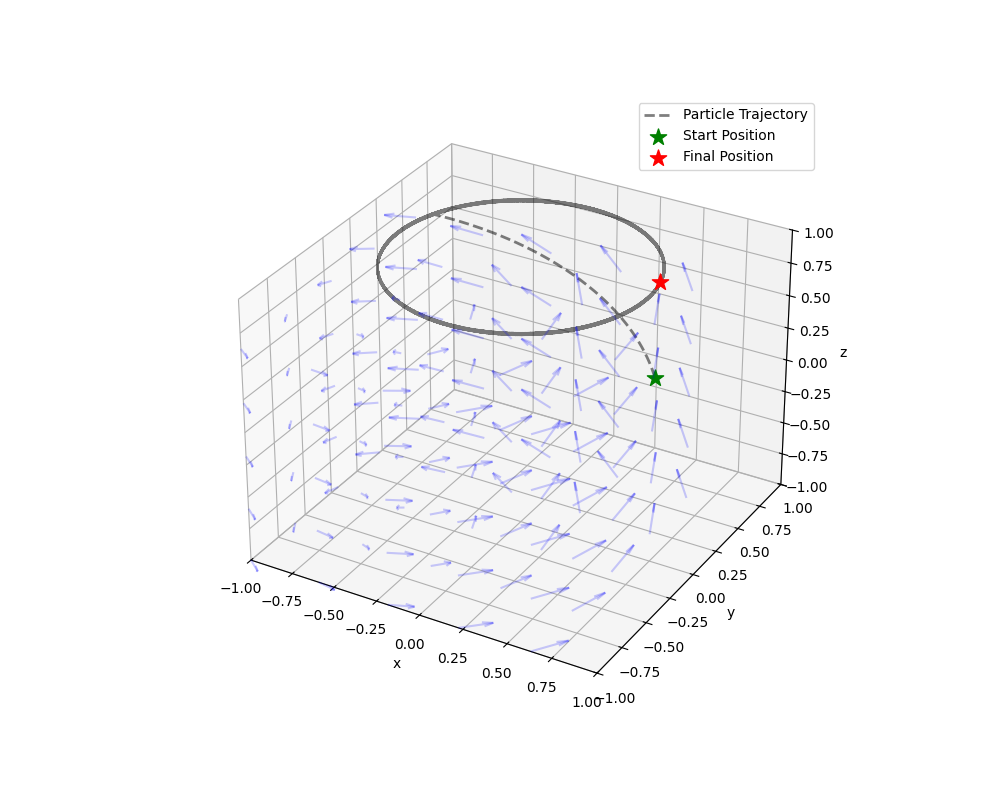

In [3]:
if __name__ == "__main__":
    box = [(-1, 1), (-1, 1), (-1, 1)]
    grid_res = (50, 50, 50)
    
    solver = ODE_solver(box_limits=box, grid_shape=grid_res)
    start_position = [0.5, 0.5, 0]
    t0, tf, step_size = 0, 100, 0.02 
    
    path = solver.solve(start_position, t0, tf, step_size)
    
    # extract x, y, z coordinates from the history for plotting
    x_coords = path[:, 0]
    y_coords = path[:, 1]
    z_coords = path[:, 2]

    # plotting 
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.plot(x_coords, y_coords, z_coords, label='Particle Trajectory', color='black', alpha=0.5, lw=2, linestyle='--') # plotting path
    ax.scatter(x_coords[0], y_coords[0], z_coords[0], color='green', s=150, marker='*',label='Start Position') 
    ax.scatter(x_coords[-1], y_coords[-1], z_coords[-1], color='red', s=150, marker='*',label='Final Position')
    
    ax.set_xlim(box[0])
    ax.set_ylim(box[1])
    ax.set_zlim(box[2])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.legend()
    ax.grid(True)


    # plotting velocity field
    skip = 10 
    X, Y, Z = np.meshgrid(
        solver.x_grid[::skip],
        solver.y_grid[::skip],
        solver.z_grid[::skip]
    )

    U = -Y
    V = X
    W = 0.5 * np.ones_like(Z)

    ax.quiver(
        X, Y, Z,
        U, V, W,
        length=0.2,
        normalize=True,
        color='blue',
        alpha=0.2
    )

    plt.show()